## Класифікація Fashion-MNIST за допомогою Keras

Oпис датасету:
https://www.tensorflow.org/datasets/catalog/fashion_mnist

In [215]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Reproducibility
tf.keras.utils.set_random_seed(42)


### Завантаження датасету

In [216]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

### Назви класів та приклади зображень

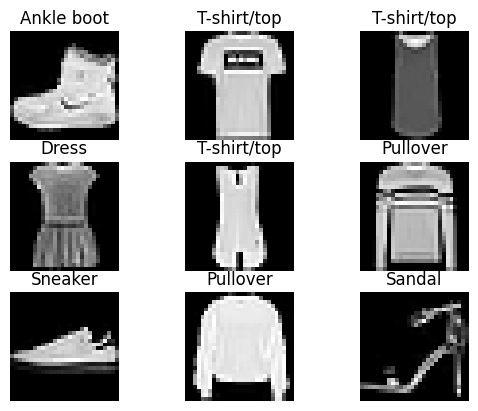

In [217]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure()
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.show()

### Попередня обробка даних

In [218]:
x_train = (x_train.astype("float32") / 255.0)[..., np.newaxis]
x_test  = (x_test.astype("float32") / 255.0)[..., np.newaxis]

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)

x_train: (60000, 28, 28, 1)
x_test: (10000, 28, 28, 1)


### Побудова data pipeline

In [219]:
batch_size = 128

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(20000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [220]:
for xb, yb in train_ds.take(1):
    print("Batch x shape:", xb.shape)
    print("Batch y shape:", yb.shape)

Batch x shape: (128, 28, 28, 1)
Batch y shape: (128,)


### Mодель CNN

In [221]:
inputs = tf.keras.layers.Input(shape=(28, 28, 1))
x = inputs

x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(10, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,818 (1.78 MB)

 Trainable params: 467,818 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

### Callbacks

In [222]:
class StopOnValAccDropAfterTarget(tf.keras.callbacks.Callback):
    def __init__(self, target=0.91, monitor="val_accuracy", verbose=1):
        super().__init__()
        self.target = target
        self.monitor = monitor
        self.verbose = verbose
        self.prev = None
        self.target_reached = False

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)

        if current is None:
            return

        if current >= self.target:
            self.target_reached = True

        if self.target_reached and self.prev is not None and self.prev > current:
            if self.verbose:
                print(
                    f"\nStopped: {self.monitor} dropped from {self.prev:.4f} to {current:.4f} "
                    f"after reaching target {self.target:.2f}."
                )
            self.model.stop_training = True

        self.prev = current
        
callbacks = [
    StopOnValAccDropAfterTarget(target=0.91, monitor="val_accuracy", verbose=1),
]

### Навчання CNN

In [223]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=2
)


test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")


Epoch 1/50
469/469 - 28s - 59ms/step - accuracy: 0.8038 - loss: 0.5357 - val_accuracy: 0.8789 - val_loss: 0.3347
Epoch 2/50
469/469 - 25s - 54ms/step - accuracy: 0.8813 - loss: 0.3243 - val_accuracy: 0.8985 - val_loss: 0.2780
Epoch 3/50
469/469 - 22s - 47ms/step - accuracy: 0.9010 - loss: 0.2722 - val_accuracy: 0.9133 - val_loss: 0.2399
Epoch 4/50
469/469 - 21s - 45ms/step - accuracy: 0.9099 - loss: 0.2470 - val_accuracy: 0.9175 - val_loss: 0.2264
Epoch 5/50
469/469 - 27s - 57ms/step - accuracy: 0.9186 - loss: 0.2231 - val_accuracy: 0.9194 - val_loss: 0.2187
Epoch 6/50
469/469 - 27s - 57ms/step - accuracy: 0.9238 - loss: 0.2090 - val_accuracy: 0.9216 - val_loss: 0.2151
Epoch 7/50
469/469 - 23s - 50ms/step - accuracy: 0.9288 - loss: 0.1965 - val_accuracy: 0.9286 - val_loss: 0.2001
Epoch 8/50
469/469 - 27s - 57ms/step - accuracy: 0.9317 - loss: 0.1845 - val_accuracy: 0.9299 - val_loss: 0.1972
Epoch 9/50
469/469 - 27s - 57ms/step - accuracy: 0.9355 - loss: 0.1739 - val_accuracy: 0.9308 - 

### Аналіз навчання

In [224]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 0.9323
Test loss: 0.1942


### Графіки accuracy та loss

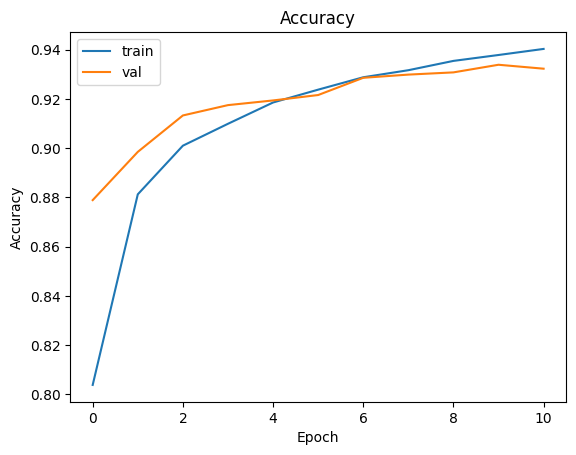

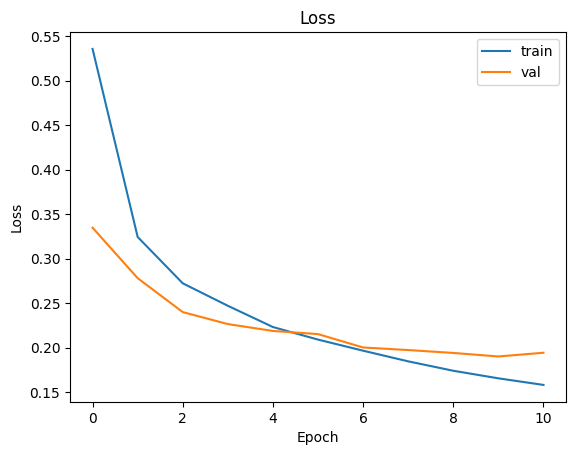

In [225]:
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["train", "val"])
plt.show()

plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["train", "val"])
plt.show()


### Діагностика проблем навчання

In [226]:
train_acc = history.history["accuracy"][-1]
val_acc = history.history["val_accuracy"][-1]
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

print("Last epoch train acc:", train_acc)
print("Last epoch val acc:", val_acc)
print("Last epoch train loss:", train_loss)
print("Last epoch val loss:", val_loss)

if train_acc < 0.90 and val_acc < 0.90:
    print("underfitting.")
elif train_acc - val_acc > 0.03 and val_loss > train_loss:
    print("overfitting.")
else:
    print("training ok.")

Last epoch train acc: 0.9403333067893982
Last epoch val acc: 0.9322999715805054
Last epoch train loss: 0.15801015496253967
Last epoch val loss: 0.19417588412761688
training ok.


### Приклади *неправильних* прогнозів

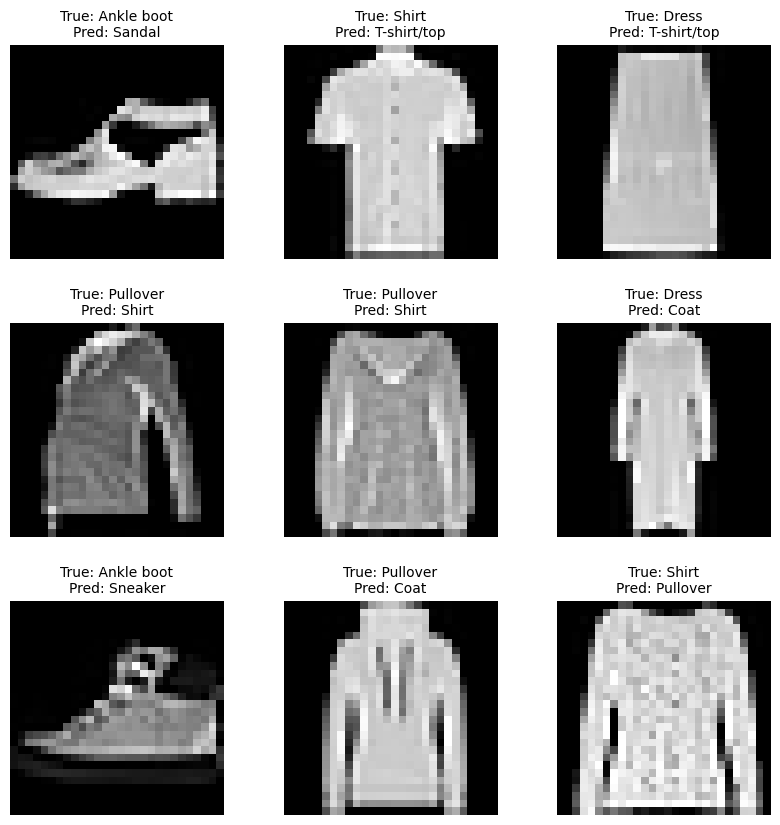

In [227]:
plt.figure(figsize=(10, 10))

for i, idx in enumerate(wrong_idx):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap="gray")
    plt.title(
        f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}",
        fontsize=10
    )
    plt.axis("off")

plt.subplots_adjust(hspace=0.3)

plt.show()

### Приклади *правильних* передбачень

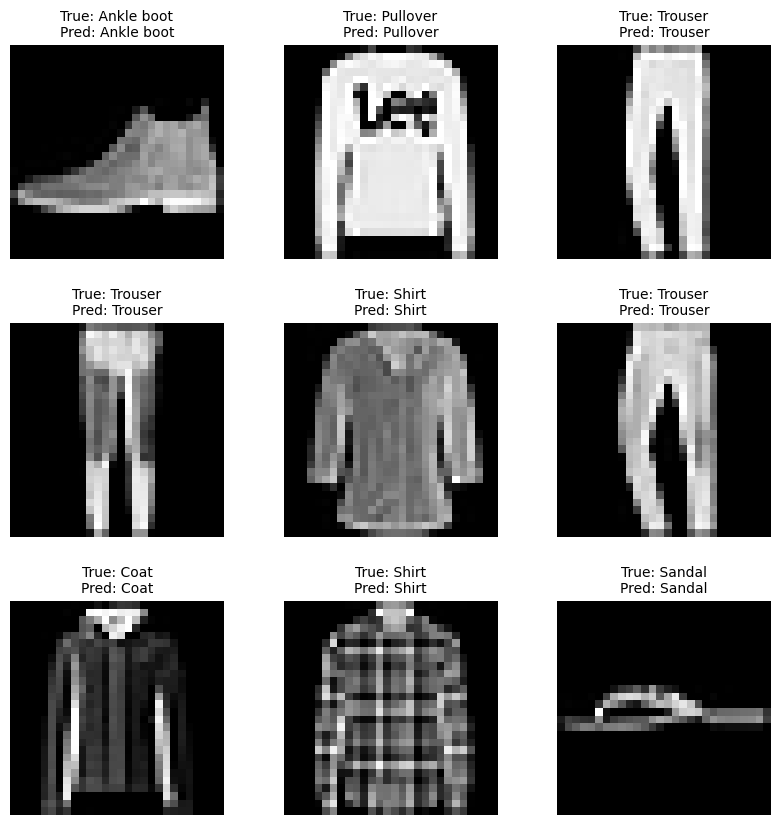

In [228]:
plt.figure(figsize=(10, 10))

for i, idx in enumerate(correct_idx):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap="gray")
    plt.title(
        f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}",
        fontsize=10
    )
    plt.axis("off")

plt.subplots_adjust(hspace=0.3)

plt.show()

## Висновки

- CNN-модель, що використовує згорткові шари, витягує просторові ознаки зображень.
- Використання Dropout зменшує ризик перенавчання.
- Отримана точність на тесті відповідає вимозі "не нижчою 91%"